# Bregman Proximal Point Method (BPPM)

This notebook starts the PEPFlow Lyapunov workflow for the Bregman proximal point method. Let $f$ be closed, proper, convex, and differentiable relative to the Bregman kernel $h$. Let $h$ be closed, proper, convex, and differentiable, and define

$$D_h(u,v)=h(u)-h(v)-\langle \nabla h(v),u-v\rangle.$$

The method uses the fixed step size $\alpha>0$:

$$x_{k+1}=\operatorname{prox}^{h}_{\alpha f}(x_k), \qquad k\ge 0.$$

The initial condition is $D_h(x_\star,x_0)\le R$, where $x_\star$ minimizes $f$, and the performance metric is $f(x_N)-f(x_\star)$. The candidate rate is

$$f(x_N)-f(x_\star)\le \frac{R}{\alpha N}.$$

## Proof Statement

### Theorem

Assume $f$ is closed, proper, convex, and differentiable relative to the Bregman kernel $h$, and assume $h$ is closed, proper, convex, and differentiable. Let

$$
D_h(u,v)=h(u)-h(v)-\langle \nabla h(v),u-v\rangle.
$$

Run the Bregman proximal point method with fixed $\alpha>0$,

$$
x_{k+1}=\operatorname{prox}^{h}_{\alpha f}(x_k),\qquad k\ge 0,
$$

equivalently $\alpha\nabla f(x_{k+1})+\nabla h(x_{k+1})-\nabla h(x_k)=0$. If $x_\star\in\operatorname{argmin} f$ and $D_h(x_\star,x_0)\le R$, then for every $N\ge 1$,

$$
f(x_N)-f(x_\star)\le \frac{R}{\alpha N}.
$$

The Lyapunov certificate recovered below is

$$
V_k=\frac{k}{N}\left(f(x_k)-f(x_\star)\right)
+\frac{D_h(x_\star,x_k)-D_h(x_\star,x_0)}{\alpha N},\qquad 1\le k<N,
$$

with terminal form

$$
V_N=f(x_N)-f(x_\star)-\frac{D_h(x_\star,x_0)}{\alpha N}.
$$

### Proof outline

For any convex function $g$, write the interpolation residual as

$$
I_g(u,v)=g(u)-g(v)-\langle \nabla g(v),u-v\rangle\le 0.
$$

The BPPM optimality condition is encoded by PEPFlow as

$$
\nabla h(x_{k+1})=\nabla h(x_k)-\alpha\nabla f(x_{k+1}).
$$

The first step satisfies

$$
V_1=\frac{1}{N}I_f(x_\star,x_1)+\frac{1}{\alpha N}I_h(x_1,x_0)\le 0.
$$

For $1\le k<N-1$,

$$
\begin{aligned}
V_{k+1}-V_k
={}&\frac{1}{N}I_f(x_\star,x_{k+1})
+\frac{k}{N}I_f(x_k,x_{k+1})\\
&+\frac{k+1}{\alpha N}I_h(x_{k+1},x_k)
+\frac{k}{\alpha N}I_h(x_k,x_{k+1})\le 0.
\end{aligned}
$$

The final step has the same form with $k=N-1$ and the extra boundary interpolation residual:

$$
\begin{aligned}
V_N-V_{N-1}
={}&\frac{1}{N}I_f(x_\star,x_N)
+\frac{N-1}{N}I_f(x_{N-1},x_N)
+\frac{1}{\alpha}I_h(x_N,x_{N-1})\\
&+\frac{N-1}{\alpha N}I_h(x_{N-1},x_N)
+\frac{1}{\alpha N}I_h(x_\star,x_N)\le 0.
\end{aligned}
$$

Thus $V_N\le V_{N-1}\le\cdots\le V_1\le 0$. Finally,

$$
f(x_N)-f(x_\star)-\frac{R}{\alpha N}
=V_N+\frac{D_h(x_\star,x_0)-R}{\alpha N}\le 0,
$$

because $D_h(x_\star,x_0)-R\le 0$.

In [1]:
from pathlib import Path
import importlib.util
import json
import sys
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pepflow as pf  # noqa: E402
from pepflow.lyapunov_utils import (  # noqa: E402
    find_symmetric_coefficient_matrix,
    vectors_in_column_space,
)

In [2]:
alpha = pf.Parameter("alpha")
R = pf.Parameter("R")
f = pf.ConvexFunction(is_basis=True, tags=["f"])
h = pf.ConvexFunction(is_basis=True, tags=["h"])


def make_ctx_bppm(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    f.set_stationary_point("x_star")

    for k in range(int(N)):
        x = f.bregman_prox(x, alpha, h, tag=f"x_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    ctx = make_ctx_bppm(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    x_0 = ctx["x_0"]
    x_star = ctx["x_star"]
    pb.add_initial_constraint(
        (h(x_star) - h(x_0) - h.grad(x_0) * (x_star - x_0)).le(
            R, name="initial_condition"
        )
    )
    pb.set_performance_metric(f(ctx[f"x_{N}"]) - f(x_star))
    return ctx, pb, f

N=1: 0.99999943
N=2: 0.49999429
N=3: 0.33332395
N=4: 0.25000574
N=5: 0.19999916
N=6: 0.16666666
N=7: 0.14285797


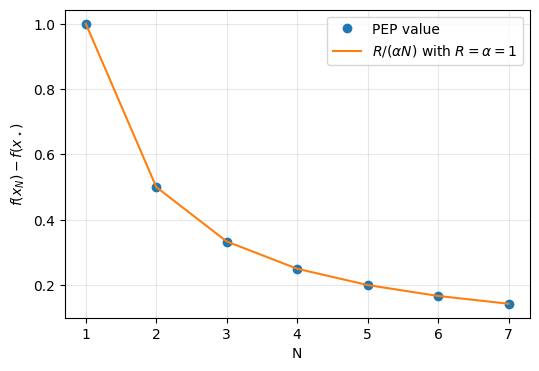

In [3]:
state_path = repo_root / "examples_peppy" / "bppm" / "state" / "bppm_b1.json"
with state_path.open() as fh:
    state = json.load(fh)
sweep_results = state["sweep_results"]

Ns = [row["N"] for row in sweep_results]
values = [row["opt_value"] for row in sweep_results]
rate = [1.0 / N for N in Ns]

for N, value in zip(Ns, values):
    print(f"N={N}: {value:.8f}")

plt.figure(figsize=(6, 4))
plt.plot(Ns, values, "o", label="PEP value")
plt.plot(Ns, rate, "-", label=r"$R/(\alpha N)$ with $R=\alpha=1$")
plt.xlabel("N")
plt.ylabel(r"$f(x_N)-f(x_\star)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Block 1 Summary

The initial numerical evidence matches the conjectured rate $R/(\alpha N)$ for $R=1$ and $\alpha=1$.

## Dense And Relaxed Proof Solves

Block 2 solves the full PEP at $N=4$, then enforces a sparse certificate containing only the inequalities needed for the Bregman telescoping proof.

In [4]:
b2_path = repo_root / "examples_peppy" / "bppm" / "state" / "bppm_b2.json"
with b2_path.open() as fh:
    b2 = json.load(fh)

print(f"Dense optimum:  {b2['dense_opt_value']:.8f}")
print(f"Relaxed optimum: {b2['opt_value']:.8f}")
print(f"Tau:             {b2['tau_sol']:.8f}")
print(f"Dropped constraints: {len(b2['relaxed_constraints'])}")
print("Active f inequalities:")
for row, col, coeff in b2["active_lambda_f_entries"]:
    print(f"  f:{row},{col}  coeff={coeff}")
print("Active h inequalities:")
for row, col, coeff in b2["active_lambda_h_entries"]:
    print(f"  h:{row},{col}  coeff={coeff}")

Dense optimum:  0.25000574
Relaxed optimum: 0.24999855
Tau:             0.25000028
Dropped constraints: 35
Active f inequalities:
  f:x_star,x_1  coeff=1/4
  f:x_star,x_2  coeff=1/4
  f:x_star,x_3  coeff=1/4
  f:x_star,x_4  coeff=1/4
  f:x_1,x_2  coeff=1/4
  f:x_2,x_3  coeff=2/4
  f:x_3,x_4  coeff=3/4
Active h inequalities:
  h:x_1,x_0  coeff=1/(alpha*4)
  h:x_2,x_1  coeff=2/(alpha*4)
  h:x_3,x_2  coeff=3/(alpha*4)
  h:x_4,x_3  coeff=4/(alpha*4)
  h:x_1,x_2  coeff=1/(alpha*4)
  h:x_2,x_3  coeff=2/(alpha*4)
  h:x_3,x_4  coeff=3/(alpha*4)
  h:x_star,x_4  coeff=1/(alpha*4)


## Closed-Form Certificate

The relaxed certificate uses two families of function inequalities. For $f$, the nonzero multipliers are

$$\lambda^f_{x_\star,x_i}=\frac{1}{N},\qquad \lambda^f_{x_i,x_{i+1}}=\frac{i}{N}.$$

For the Bregman kernel $h$, the nonzero multipliers are

$$\lambda^h_{x_i,x_{i-1}}=\frac{i}{\alpha N},\qquad \lambda^h_{x_i,x_{i+1}}=\frac{i}{\alpha N},\qquad \lambda^h_{x_\star,x_N}=\frac{1}{\alpha N}.$$

In [5]:
N_int = b2["N_verify"]
alpha_value = sp.S(1)


def tag_to_index(tag, N=N_int):
    return N + 1 if tag == "x_star" else int(tag.split("_")[1])


def lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1 and 1 <= j <= N:
        return sp.Rational(1, N)
    if 1 <= i < N and j == i + 1:
        return sp.Rational(i, N)
    return sp.S(0)


def h_lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if 1 <= i <= N and j == i - 1:
        return sp.Rational(i, 1) / (alpha_value * N)
    if 1 <= i < N and j == i + 1:
        return sp.Rational(i, 1) / (alpha_value * N)
    if i == N + 1 and j == N:
        return sp.S(1) / (alpha_value * N)
    return sp.S(0)


f_rows, f_cols = b2["lambda_f_row_names"], b2["lambda_f_col_names"]
h_rows, h_cols = b2["lambda_h_row_names"], b2["lambda_h_col_names"]
lambda_f_cand = np.array(
    [[lamb(ri, ci) for ci in f_cols] for ri in f_rows], dtype=object
)
lambda_h_cand = np.array(
    [[h_lamb(ri, ci) for ci in h_cols] for ri in h_rows], dtype=object
)
lambda_f_num = np.array(b2["lambda_f_matrix"], dtype=float)
lambda_h_num = np.array(b2["lambda_h_matrix"], dtype=float)
print(
    "f lambda max residual:",
    np.max(np.abs(lambda_f_num - np.array(lambda_f_cand, dtype=float))),
)
print(
    "h lambda max residual:",
    np.max(np.abs(lambda_h_num - np.array(lambda_h_cand, dtype=float))),
)
pf.pprint_labeled_matrix(lambda_f_cand, f_rows, f_cols, precision=None)
pf.pprint_labeled_matrix(lambda_h_cand, h_rows, h_cols, precision=None)

f lambda max residual: 4.872105814623939e-07
h lambda max residual: 1.162613091132414e-06


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## S Decomposition

The sparse proof has a zero Gram certificate: the scalar interpolation inequalities telescope exactly, leaving no additional squared term.

In [6]:
b5_path = repo_root / "examples_peppy" / "bppm" / "state" / "bppm_b5.json"
with b5_path.open() as fh:
    b5 = json.load(fh)

S_numeric = np.array(b2["S_matrix"], dtype=float)
S_guess = np.zeros_like(S_numeric)
print("S max absolute entry:", np.max(np.abs(S_numeric)))
print("S zero-certificate match:", np.allclose(S_guess, S_numeric, atol=1e-8))
pf.pprint_labeled_matrix(S_numeric, b2["S_row_names"], b2["S_col_names"])
pf.pprint_str(b5["S_formula"])

S max absolute entry: 2.087158612340433e-15
S zero-certificate match: True


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Symbolic Verification

At $N=4$, the exact identity is

$$f(x_N)-f(x_\star)-\frac{R}{\alpha N}-\frac{1}{\alpha N}\left(D_h(x_\star,x_0)-R\right)-\sum \lambda^f I_f-\sum \lambda^h I_h=0.$$

In [7]:
spec = importlib.util.spec_from_file_location(
    "bppm_setup", repo_root / "examples_peppy" / "bppm" / "bppm_setup.py"
)
if spec is None or spec.loader is None:
    raise ImportError("Could not load bppm_setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

ctx, pb, obj = setup.get_pep_setup(sp.S(N_int), {"alpha": sp.S(1), "R": sp.S(1)})
pm = pf.ExpressionManager(ctx, resolve_parameters={"alpha": sp.S(1), "R": sp.S(1)})
x = {i: ctx[f"x_{i}"] for i in range(N_int + 1)}
x_star = ctx["x_star"]
D0 = setup.h(x_star) - setup.h(x[0]) - setup.h.grad(x[0]) * (x_star - x[0])
IC = D0 - setup.R
perf = setup.f(x[N_int]) - setup.f(x_star)
tau = sp.S(1) / (setup.alpha * N_int)

interp = pf.Scalar.zero()
for i in range(1, N_int + 1):
    interp += sp.S(1) / N_int * setup.f.interp_ineq("x_star", f"x_{i}")
for i in range(1, N_int):
    interp += sp.S(i) / N_int * setup.f.interp_ineq(f"x_{i}", f"x_{i + 1}")
for i in range(1, N_int + 1):
    interp += (
        sp.S(i) / (setup.alpha * N_int) * setup.h.interp_ineq(f"x_{i}", f"x_{i - 1}")
    )
for i in range(1, N_int):
    interp += (
        sp.S(i) / (setup.alpha * N_int) * setup.h.interp_ineq(f"x_{i}", f"x_{i + 1}")
    )
interp += sp.S(1) / (setup.alpha * N_int) * setup.h.interp_ineq("x_star", f"x_{N_int}")

proof_residual = perf - setup.R / (setup.alpha * N_int) - tau * IC - interp
ev = pm.eval_scalar(proof_residual)
proof_residual_np = np.array(ev.inner_prod_coords, dtype=float)
proof_func_np = np.array(ev.func_coords, dtype=float)
print(
    "Proof valid:",
    np.allclose(proof_residual_np, 0, atol=1e-10)
    and np.allclose(proof_func_np, 0, atol=1e-10)
    and ev.offset == 0,
)
print("Matrix residual max:", np.max(np.abs(proof_residual_np)))
print("Function residual max:", np.max(np.abs(proof_func_np)))
print("Offset:", ev.offset)
pf.pprint_labeled_matrix(
    proof_residual_np, b2["S_row_names"], b2["S_col_names"], precision=None
)

Proof valid: True
Matrix residual max: 0.0
Function residual max: 0.0
Offset: 0


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




<IPython.core.display.Math object>

## Lyapunov Construction

Define $V_0=0$ and group the dual certificate by step. At step $k+1$, the increment is

$$V_{k+1}-V_k=\frac{1}{N}I_f(x_\star,x_{k+1})+\mathbf{1}_{k\ge 1}\frac{k}{N}I_f(x_k,x_{k+1})+\frac{k+1}{\alpha N}I_h(x_{k+1},x_k)+\mathbf{1}_{k\ge 1}\frac{k}{\alpha N}I_h(x_k,x_{k+1}),$$

with the final boundary term $\frac{1}{\alpha N}I_h(x_\star,x_N)$ added at $k=N-1$. Each interpolation residual is nonpositive, so this convention makes $V_k$ nonincreasing. The interior rank is constant for $k=1,\ldots,N-1$.

In [8]:
b3_path = repo_root / "examples_peppy" / "bppm" / "state" / "bppm_b3.json"
with b3_path.open() as fh:
    b3 = json.load(fh)

N_int = b3["N_verify"]
rank_tolerance = b3["rank_tolerance"]
f = setup.f
h = setup.h
alpha = setup.alpha

ctx, pb, obj = setup.get_pep_setup(sp.S(N_int), {"alpha": sp.S(1), "R": sp.S(1)})
pm = pf.ExpressionManager(ctx, resolve_parameters={"alpha": sp.S(1), "R": sp.S(1)})

lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for step in range(N_int):
    i = step + 1
    partial_sum += sp.S(1) / N_int * f.interp_ineq("x_star", f"x_{i}")
    if i >= 2:
        partial_sum += sp.S(i - 1) / N_int * f.interp_ineq(f"x_{i - 1}", f"x_{i}")
    partial_sum += sp.S(i) / (alpha * N_int) * h.interp_ineq(f"x_{i}", f"x_{i - 1}")
    if i >= 2:
        partial_sum += (
            sp.S(i - 1) / (alpha * N_int) * h.interp_ineq(f"x_{i - 1}", f"x_{i}")
        )
    if i == N_int:
        partial_sum += sp.S(1) / (alpha * N_int) * h.interp_ineq("x_star", f"x_{N_int}")
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 4
rank V_2: 4
rank V_3: 4
rank V_4: 2
Interior rank is constant: True


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



In [9]:
x = {i: ctx[f"x_{i}"] for i in range(N_int + 1)}
x_star = ctx["x_star"]
D0 = h(x_star) - h(x[0]) - h.grad(x[0]) * (x_star - x[0])
IC = D0 - setup.R
boundary = (
    f(x[N_int]) - f(x_star) - setup.R / (alpha * N_int) - sp.S(1) / (alpha * N_int) * IC
)
coverage = lyap[N_int] - boundary
coverage_eval = pm.eval_scalar(coverage)
coverage_matrix = coverage_eval.inner_prod_coords.astype(float)
coverage_func = coverage_eval.func_coords.astype(float)
print(f"lyap[{N_int}] rank:", ranks[N_int])
print("Coverage matrix max:", np.max(np.abs(coverage_matrix)))
print("Coverage function max:", np.max(np.abs(coverage_func)))
print("Coverage offset:", coverage_eval.offset)
print("Stored rank profile:", b3["rank_profile"])

lyap[4] rank: 2
Coverage matrix max: 0.0
Coverage function max: 0.0
Coverage offset: 0
Stored rank profile: [0, 4, 4, 4, 2]


## Identify the vectors composing the Lyapunov function

Block 4 starts from the verified partial sums and searches for interpretable vectors spanning the inner-product part of each $V_k$. For BPPM the function-value coordinates are kept separately, because the low-rank matrix only represents the Bregman cross terms.

In [10]:
b4_path = repo_root / "examples_peppy" / "bppm" / "state" / "bppm_b4.json"
with b4_path.open() as fh:
    b4 = json.load(fh)

rank_check = []
for Vk in lyap:
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank_check.append(int(np.linalg.matrix_rank(matrix, tol=b4["rank_tolerance"])))
print("Rank profile:", rank_check)
print("Stored profile:", b4["rank_profile"])
assert rank_check == b4["rank_profile"]

Rank profile: [0, 4, 4, 4, 2]
Stored profile: [0, 4, 4, 4, 2]


### Candidate-vector scan

The candidate family includes tagged iterates, point-to-solution gaps, the available $h$-gradients, and simple $h$-gradient increments suggested by the Bregman prox relation.

In [11]:
candidates = []
_seen = set()


def add_candidate(label, vector):
    coords = pm.eval_vector(vector).coords.astype(float)
    if np.linalg.norm(coords) < 1e-10:
        return
    key = tuple(np.round(coords, 10))
    if key in _seen:
        return
    _seen.add(key)
    candidates.append((label, vector))


for i in range(N_int + 1):
    add_candidate(f"x_{i}", ctx[f"x_{i}"])
    add_candidate(f"x_{i} - x_star", ctx[f"x_{i}"] - ctx["x_star"])
add_candidate("x_star", ctx["x_star"])
add_candidate("grad_h(x_0)", h.grad(ctx["x_0"]))
add_candidate("grad_h(x_star)", h.grad(ctx["x_star"]))
for i in range(1, N_int + 1):
    add_candidate(f"grad_h(x_{i})", h.grad(ctx[f"x_{i}"]))
    add_candidate(
        f"grad_h(x_0)-grad_h(x_{i})", h.grad(ctx["x_0"]) - h.grad(ctx[f"x_{i}"])
    )

print(f"{len(candidates)} unique candidates")

21 unique candidates


In [12]:
candidate_vectors = [vector for _, vector in candidates]
for k in range(1, N_int + 1):
    in_col = vectors_in_column_space(
        lyap[k],
        candidate_vectors,
        pep_context=ctx,
        resolve_parameters={"alpha": sp.S(1), "R": sp.S(1)},
        rtol=1e-4,
        atol=1e-4,
    )
    print(f"V_{k} column-space candidates:")
    for vector in in_col:
        coords = pm.eval_vector(vector).coords.astype(float)
        label = next(
            label
            for label, candidate in candidates
            if np.linalg.norm(coords - pm.eval_vector(candidate).coords.astype(float))
            < 1e-8
        )
        print("  ", label)

V_1 column-space candidates:
   x_0 - x_star
   x_1 - x_star
   grad_h(x_0)
   grad_h(x_1)
   grad_h(x_0)-grad_h(x_1)
V_2 column-space candidates:
   x_0 - x_star
   x_2 - x_star
   grad_h(x_0)
   grad_h(x_2)
   grad_h(x_0)-grad_h(x_2)
V_3 column-space candidates:
   x_0 - x_star
   x_3 - x_star
   grad_h(x_0)
   grad_h(x_3)
   grad_h(x_0)-grad_h(x_3)
V_4 column-space candidates:
   x_0 - x_star
   grad_h(x_0)


### Selected basis pattern

For $1 \le k < N$, the rank-spanning geometric basis is

$$[x_0-x_\star,\; x_k-x_\star,\; 
abla h(x_0),\; 
abla h(x_k)].$$

At the terminal point the final boundary interpolation cancels the $x_N$ Bregman term, leaving the rank-two basis

$$[x_0-x_\star,\; 
abla h(x_0)].$$

In [13]:
def V_k_basis(k):
    if 1 <= k < N_int:
        return [
            ctx["x_0"] - ctx["x_star"],
            ctx[f"x_{k}"] - ctx["x_star"],
            h.grad(ctx["x_0"]),
            h.grad(ctx[f"x_{k}"]),
        ]
    if k == N_int:
        return [ctx["x_0"] - ctx["x_star"], h.grad(ctx["x_0"])]
    return []


def V_k_basis_labels(k):
    if 1 <= k < N_int:
        return ["x_0 - x_star", f"x_{k} - x_star", "grad_h(x_0)", f"grad_h(x_{k})"]
    if k == N_int:
        return ["x_0 - x_star", "grad_h(x_0)"]
    return []


for k in range(1, N_int + 1):
    B = np.column_stack([pm.eval_vector(v).coords.astype(float) for v in V_k_basis(k)])
    print(
        f"k={k}: rank {np.linalg.matrix_rank(B, tol=1e-8)} basis {V_k_basis_labels(k)}"
    )

k=1: rank 4 basis ['x_0 - x_star', 'x_1 - x_star', 'grad_h(x_0)', 'grad_h(x_1)']
k=2: rank 4 basis ['x_0 - x_star', 'x_2 - x_star', 'grad_h(x_0)', 'grad_h(x_2)']
k=3: rank 4 basis ['x_0 - x_star', 'x_3 - x_star', 'grad_h(x_0)', 'grad_h(x_3)']
k=4: rank 2 basis ['x_0 - x_star', 'grad_h(x_0)']


### Coefficient matrices

The interior basis order is $[x_0-x_\star, x_k-x_\star, 
abla h(x_0), 
abla h(x_k)]$. The terminal basis order is $[x_0-x_\star, 
abla h(x_0)]$.

In [14]:
def coeff_pattern(k, N, alpha):
    c = sp.S(1) / (2 * alpha * N)
    if 1 <= k < N:
        C = sp.zeros(4, 4)
        C[0, 2] = C[2, 0] = -c
        C[1, 3] = C[3, 1] = c
        return C
    if k == N:
        C = sp.zeros(2, 2)
        C[0, 1] = C[1, 0] = -c
        return C
    return sp.zeros(0, 0)


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k],
        basis,
        pep_context=ctx,
        resolve_parameters={"alpha": sp.S(1), "R": sp.S(1)},
    )
    C_formula = np.array(coeff_pattern(k, N_int, sp.S(1)).tolist(), dtype=float)
    print(f"k={k} decomposed coefficients")
    pf.pprint_labeled_matrix(C, labels, labels, precision=None)
    print(f"k={k} closed-form coefficients")
    pf.pprint_labeled_matrix(C_formula, labels, labels, precision=None)
    print(f"k={k} formula residual: {np.max(np.abs(C - C_formula)):.2e}")

k=1 decomposed coefficients


<IPython.core.display.Math object>

k=1 closed-form coefficients


<IPython.core.display.Math object>

k=1 formula residual: 8.83e-17
k=2 decomposed coefficients


...

k=3 formula residual: 1.11e-16
k=4 decomposed coefficients


<IPython.core.display.Math object>

k=4 closed-form coefficients


<IPython.core.display.Math object>

k=4 formula residual: 0.00e+00


### Block 4 conclusion

The recovered Lyapunov candidate is

$$
V_k=\frac{k}{N}\bigl(f(x_k)-f(x_\star)\bigr)+\frac{D_h(x_\star,x_k)-D_h(x_\star,x_0)}{\alpha N},\qquad 1\le k<N,
$$

with terminal form

$$
V_N=f(x_N)-f(x_\star)-\frac{D_h(x_\star,x_0)}{\alpha N}.
$$

The next section symbolically verifies the one-step recursion, the base case, the terminal step, and the boundary identity for this closed form.

## Symbolic Step Recursion Verification

For $1\le k<N-1$, this cell verifies

$$
\mathrm{LHS}-\mathrm{RHS}
=(V_{k+1}-V_k)-\left[
\frac{1}{N}I_f(x_\star,x_{k+1})
+\frac{k}{N}I_f(x_k,x_{k+1})
+\frac{k+1}{\alpha N}I_h(x_{k+1},x_k)
+\frac{k}{\alpha N}I_h(x_k,x_{k+1})
\right].
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [15]:
def _register_values(funcs: list[Any], points: list[Any]) -> None:
    for func in funcs:
        for point in points:
            func(point)
            func.grad(point)


def _D_h(func_h: Any, u: Any, v: Any) -> Any:
    return func_h(u) - func_h(v) - func_h.grad(v) * (u - v)


def _V_interior(
    idx: Any,
    x_cur: Any,
    x_anchor: Any,
    x_star: Any,
    func_f: Any,
    func_h: Any,
    alpha_param: Any,
    N_param: Any,
) -> Any:
    return idx / N_param * (func_f(x_cur) - func_f(x_star)) + (
        _D_h(func_h, x_star, x_cur) - _D_h(func_h, x_star, x_anchor)
    ) / (alpha_param * N_param)


def _V_terminal(
    x_cur: Any,
    x_anchor: Any,
    x_star: Any,
    func_f: Any,
    func_h: Any,
    alpha_param: Any,
    N_param: Any,
) -> Any:
    return (
        func_f(x_cur)
        - func_f(x_star)
        - _D_h(func_h, x_star, x_anchor) / (alpha_param * N_param)
    )


def _simplified_residual(
    diff: Any, ctx_obj: Any, resolve_parameters: dict[str, Any]
) -> tuple[Any, Any]:
    pm_obj = pf.ExpressionManager(ctx_obj, resolve_parameters=resolve_parameters)
    evaluated = pm_obj.eval_scalar(diff)
    matrix = sp.Matrix(evaluated.inner_prod_coords).applyfunc(
        lambda expr: sp.factor(sp.cancel(sp.simplify(sp.nsimplify(expr))))
    )
    funcs = sp.Matrix(evaluated.func_coords).applyfunc(
        lambda expr: sp.factor(sp.cancel(sp.simplify(sp.nsimplify(expr))))
    )
    return matrix, funcs


def _all_zero(matrix: Any) -> bool:
    return all(entry == 0 for entry in list(matrix))


def _show_residual(name: str, matrix: Any, funcs: Any, ctx_obj: Any) -> None:
    labels = ctx_obj.basis_vectors_math_exprs()
    pf.pprint_labeled_matrix(
        np.array(matrix.tolist(), dtype=object), labels, labels, precision=None
    )
    func_labels = ctx_obj.basis_scalars_math_exprs()
    print(f"{name} matrix zero:", _all_zero(matrix))
    print(f"{name} function residuals:", dict(zip(func_labels, list(funcs))))
    print(f"{name} function zero:", _all_zero(funcs))


ctx_step = pf.PEPContext("bppm_step_symbolic").set_as_current()
alpha_step = pf.Parameter("alpha")
k_step = pf.Parameter("k")
N_step = pf.Parameter("N")
f_step = pf.ConvexFunction(is_basis=True, tags=["f_{step}"])
h_step = pf.ConvexFunction(is_basis=True, tags=["h_{step}"])
f_step.set_stationary_point("x_star")
xs_step = ctx_step["x_star"]
x0_step = pf.Vector(is_basis=True, tags=["x_0"])
xk_step = pf.Vector(is_basis=True, tags=["x_k"])
_register_values([f_step, h_step], [xs_step, x0_step, xk_step])
xk1_step = f_step.bregman_prox(xk_step, alpha_step, h_step, tag="x_{k+1}")
_register_values([f_step, h_step], [xk1_step])

lhs_step = _V_interior(
    k_step + 1, xk1_step, x0_step, xs_step, f_step, h_step, alpha_step, N_step
) - _V_interior(k_step, xk_step, x0_step, xs_step, f_step, h_step, alpha_step, N_step)
rhs_step = (
    sp.S(1) / N_step * f_step.interp_ineq("x_star", "x_{k+1}")
    + k_step / N_step * f_step.interp_ineq("x_k", "x_{k+1}")
    + (k_step + 1) / (alpha_step * N_step) * h_step.interp_ineq("x_{k+1}", "x_k")
    + k_step / (alpha_step * N_step) * h_step.interp_ineq("x_k", "x_{k+1}")
)
diff_step = lhs_step - rhs_step
alpha_symbol, k_symbol, N_symbol = sp.symbols("alpha k N", positive=True)
step_matrix, step_funcs = _simplified_residual(
    diff_step,
    ctx_step,
    {"alpha": alpha_symbol, "k": k_symbol, "N": N_symbol},
)
_show_residual("step", step_matrix, step_funcs, ctx_step)
assert _all_zero(step_matrix)
assert _all_zero(step_funcs)

<IPython.core.display.Math object>

step matrix zero: True
step function residuals: {'f_{step}(x_star)': 0, 'f_{step}(x_0)': 0, 'f_{step}(x_k)': 0, 'h_{step}(x_star)': 0, 'h_{step}(x_0)': 0, 'h_{step}(x_k)': 0, 'f_{step}(x_{k+1})': 0, 'h_{step}(x_{k+1})': 0}
step function zero: True


## Base Case and Boundary Symbolic Verification

The base cell verifies

$$
\mathrm{LHS}-\mathrm{RHS}
=V_1-\left[\frac{1}{N}I_f(x_\star,x_1)+\frac{1}{\alpha N}I_h(x_1,x_0)\right].
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [16]:
ctx_base = pf.PEPContext("bppm_base_symbolic").set_as_current()
alpha_base = pf.Parameter("alpha")
N_base = pf.Parameter("N")
f_base = pf.ConvexFunction(is_basis=True, tags=["f_{base}"])
h_base = pf.ConvexFunction(is_basis=True, tags=["h_{base}"])
f_base.set_stationary_point("x_star")
xs_base = ctx_base["x_star"]
x0_base = pf.Vector(is_basis=True, tags=["x_0"])
_register_values([f_base, h_base], [xs_base, x0_base])
x1_base = f_base.bregman_prox(x0_base, alpha_base, h_base, tag="x_1")
_register_values([f_base, h_base], [x1_base])

lhs_base = _V_interior(
    sp.S(1), x1_base, x0_base, xs_base, f_base, h_base, alpha_base, N_base
)
rhs_base = sp.S(1) / N_base * f_base.interp_ineq("x_star", "x_1") + sp.S(1) / (
    alpha_base * N_base
) * h_base.interp_ineq("x_1", "x_0")
diff_base = lhs_base - rhs_base
base_matrix, base_funcs = _simplified_residual(
    diff_base,
    ctx_base,
    {"alpha": alpha_symbol, "N": N_symbol},
)
_show_residual("base", base_matrix, base_funcs, ctx_base)
assert _all_zero(base_matrix)
assert _all_zero(base_funcs)

<IPython.core.display.Math object>

base matrix zero: True
base function residuals: {'f_{base}(x_star)': 0, 'f_{base}(x_0)': 0, 'h_{base}(x_star)': 0, 'h_{base}(x_0)': 0, 'f_{base}(x_1)': 0, 'h_{base}(x_1)': 0}
base function zero: True


### Terminal Step Symbolic Verification

The terminal step cell verifies

$$
\begin{aligned}
\mathrm{LHS}-\mathrm{RHS}
={}&(V_N-V_{N-1})-\bigg[
\frac{1}{N}I_f(x_\star,x_N)
+\frac{N-1}{N}I_f(x_{N-1},x_N)
+\frac{1}{\alpha}I_h(x_N,x_{N-1})\\
&+\frac{N-1}{\alpha N}I_h(x_{N-1},x_N)
+\frac{1}{\alpha N}I_h(x_\star,x_N)
\bigg].
\end{aligned}
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [17]:
ctx_terminal = pf.PEPContext("bppm_terminal_symbolic").set_as_current()
alpha_terminal = pf.Parameter("alpha")
N_terminal = pf.Parameter("N")
f_terminal = pf.ConvexFunction(is_basis=True, tags=["f_{terminal}"])
h_terminal = pf.ConvexFunction(is_basis=True, tags=["h_{terminal}"])
f_terminal.set_stationary_point("x_star")
xs_terminal = ctx_terminal["x_star"]
x0_terminal = pf.Vector(is_basis=True, tags=["x_0"])
xprev_terminal = pf.Vector(is_basis=True, tags=["x_{N-1}"])
_register_values([f_terminal, h_terminal], [xs_terminal, x0_terminal, xprev_terminal])
xn_terminal = f_terminal.bregman_prox(
    xprev_terminal, alpha_terminal, h_terminal, tag="x_N"
)
_register_values([f_terminal, h_terminal], [xn_terminal])

lhs_terminal = _V_terminal(
    xn_terminal,
    x0_terminal,
    xs_terminal,
    f_terminal,
    h_terminal,
    alpha_terminal,
    N_terminal,
) - _V_interior(
    N_terminal - 1,
    xprev_terminal,
    x0_terminal,
    xs_terminal,
    f_terminal,
    h_terminal,
    alpha_terminal,
    N_terminal,
)
rhs_terminal = (
    sp.S(1) / N_terminal * f_terminal.interp_ineq("x_star", "x_N")
    + (N_terminal - 1) / N_terminal * f_terminal.interp_ineq("x_{N-1}", "x_N")
    + sp.S(1) / alpha_terminal * h_terminal.interp_ineq("x_N", "x_{N-1}")
    + (N_terminal - 1)
    / (alpha_terminal * N_terminal)
    * h_terminal.interp_ineq("x_{N-1}", "x_N")
    + sp.S(1) / (alpha_terminal * N_terminal) * h_terminal.interp_ineq("x_star", "x_N")
)
diff_terminal = lhs_terminal - rhs_terminal
terminal_matrix, terminal_funcs = _simplified_residual(
    diff_terminal,
    ctx_terminal,
    {"alpha": alpha_symbol, "N": N_symbol},
)
_show_residual("terminal step", terminal_matrix, terminal_funcs, ctx_terminal)
assert _all_zero(terminal_matrix)
assert _all_zero(terminal_funcs)

<IPython.core.display.Math object>

terminal step matrix zero: True
terminal step function residuals: {'f_{terminal}(x_star)': 0, 'f_{terminal}(x_0)': 0, 'f_{terminal}(x_{N-1})': 0, 'h_{terminal}(x_star)': 0, 'h_{terminal}(x_0)': 0, 'h_{terminal}(x_{N-1})': 0, 'f_{terminal}(x_N)': 0, 'h_{terminal}(x_N)': 0}
terminal step function zero: True


### Boundary Identity Symbolic Verification

The boundary cell verifies

$$
\mathrm{LHS}-\mathrm{RHS}
=\left(f(x_N)-f(x_\star)-\frac{R}{\alpha N}\right)
-\left[V_N+\frac{D_h(x_\star,x_0)-R}{\alpha N}\right].
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [18]:
ctx_boundary = pf.PEPContext("bppm_boundary_symbolic").set_as_current()
alpha_boundary = pf.Parameter("alpha")
N_boundary = pf.Parameter("N")
R_boundary = pf.Parameter("R")
f_boundary = pf.ConvexFunction(is_basis=True, tags=["f_{boundary}"])
h_boundary = pf.ConvexFunction(is_basis=True, tags=["h_{boundary}"])
f_boundary.set_stationary_point("x_star")
xs_boundary = ctx_boundary["x_star"]
x0_boundary = pf.Vector(is_basis=True, tags=["x_0"])
xn_boundary = pf.Vector(is_basis=True, tags=["x_N"])
_register_values([f_boundary, h_boundary], [xs_boundary, x0_boundary, xn_boundary])

initial_residual_boundary = _D_h(h_boundary, xs_boundary, x0_boundary) - R_boundary
vn_boundary = _V_terminal(
    xn_boundary,
    x0_boundary,
    xs_boundary,
    f_boundary,
    h_boundary,
    alpha_boundary,
    N_boundary,
)
lhs_boundary = (
    f_boundary(xn_boundary)
    - f_boundary(xs_boundary)
    - R_boundary / (alpha_boundary * N_boundary)
)
rhs_boundary = vn_boundary + initial_residual_boundary / (alpha_boundary * N_boundary)
diff_boundary = lhs_boundary - rhs_boundary
R_symbol = sp.symbols("R", positive=True)
boundary_matrix, boundary_funcs = _simplified_residual(
    diff_boundary,
    ctx_boundary,
    {"alpha": alpha_symbol, "N": N_symbol, "R": R_symbol},
)
_show_residual("boundary", boundary_matrix, boundary_funcs, ctx_boundary)
assert _all_zero(boundary_matrix)
assert _all_zero(boundary_funcs)

print("Inequality direction:")
print(b5["inequality_direction"])

<IPython.core.display.Math object>

boundary matrix zero: True
boundary function residuals: {'f_{boundary}(x_star)': 0, 'f_{boundary}(x_0)': 0, 'f_{boundary}(x_N)': 0, 'h_{boundary}(x_star)': 0, 'h_{boundary}(x_0)': 0, 'h_{boundary}(x_N)': 0}
boundary function zero: True
Inequality direction:
Each ConvexFunction interpolation residual is <= 0 and all coefficients are nonnegative for alpha>0, N>=1. The initial residual D_h(x_star,x_0)-R is <=0. Thus V_k is nonincreasing and f(x_N)-f(x_star)<=R/(alpha*N).
